In [1]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Task 1: Data Preparation

Loading the Data

In [3]:
import zipfile, os

ZIP_PATH = "/content/drive/MyDrive/Colab Notebooks/AI_ML_Practice/Week 4/Copy of devnagari digit.zip" # location of my zipfile

EXTRACT_DIR = "./devnagari_dataset" # under current directory (./) create the new folder to store extracted dataset
os.makedirs(EXTRACT_DIR, exist_ok=True) # this is where it actually gets created.

# Unzip the file
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)
print(f"File '{os.path.basename(ZIP_PATH)}' unzipped to '{EXTRACT_DIR}'")

File 'Copy of devnagari digit.zip' unzipped to './devnagari_dataset'


Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


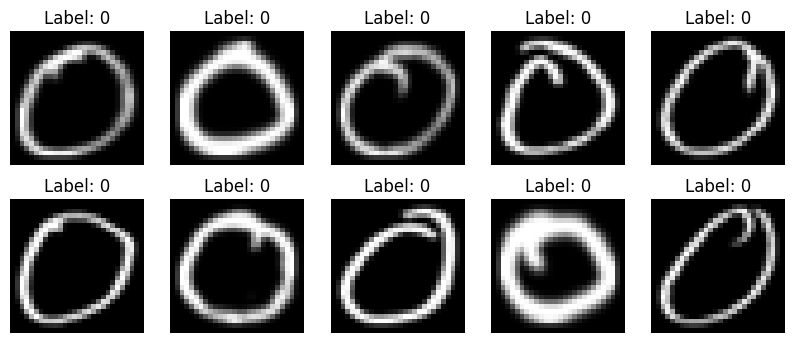

In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow


train_dir = os.path.join(EXTRACT_DIR, "DevanagariHandwrittenDigitDataset", "Train")
test_dir = os.path.join(EXTRACT_DIR, "DevanagariHandwrittenDigitDataset", "Test")

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
    class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels

    for class_name in class_names:
      class_path = os.path.join(folder, class_name)
      if not os.path.isdir(class_path): # Skip if not a directory
          continue
      label = class_map[class_name]
      for filename in os.listdir(class_path):
        img_path = os.path.join(class_path, filename)
        # Load image using PIL
        try:
          img = Image.open(img_path).convert("L")
        except:
          continue # Convert to grayscale
        img = img.resize((img_width, img_height)) # Resize to (28,28)
        img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.show() # Call plt.show() once after the loop to display all subplots

In [5]:
# Model parameters
import tensorflow as tf
from tensorflow import keras


num_classes = 10 # categories
input_shape = (28, 28, 1) #28x28 pixel image and 1-grayscale
model = keras.Sequential(
[
keras.layers.Input(shape=input_shape),   # just tells expect this size of data
keras.layers.Flatten(), # Flatten the 28x28 image to a 784
  # hidden dense layers
keras.layers.Dense(64, activation="sigmoid"),
keras.layers.Dense(128, activation="sigmoid"),
keras.layers.Dense(256, activation="sigmoid"),
  #output layer
keras.layers.Dense(num_classes, activation="softmax"),
]
)

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
optimizer="adam", # strategy for learning, Imagine you are walking down a mountain in the fog, trying to find the bottom. You take a step, check if you are lower or higher, and then adjust your next step.
loss="categorical_crossentropy", # Loss function for multi-class classification
metrics=["accuracy"] # Track accuracy during training
)

In [8]:
batch_size = 128 # at once it works for 128 image then move to next 128
epochs = 20 # iterations
# Callbacks
callbacks = [
keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
keras.callbacks.EarlyStopping(monitor="val_loss", patience=4 ), # If the model stops getting better for 4 turns (patience), stop the training early to save time
]
# Train the model with callbacks and validation split
history = model.fit(
    x_train, #  Devnagari x_train
    y_train, #  Devnagari y_train
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks,
    )

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4604 - loss: 1.6612 - val_accuracy: 0.0000e+00 - val_loss: 6.7778
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8408 - loss: 0.5244 - val_accuracy: 0.0000e+00 - val_loss: 8.0142
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9153 - loss: 0.2855 - val_accuracy: 0.0000e+00 - val_loss: 8.6428
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9430 - loss: 0.1960 - val_accuracy: 0.0000e+00 - val_loss: 9.0176
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9568 - loss: 0.1503 - val_accuracy: 0.0000e+00 - val_loss: 9.2370


In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

94/94 - 0s - 2ms/step - accuracy: 0.7613 - loss: 1.9795
Test accuracy: 0.7613


In [10]:
model.save('mnist_fully_connected_model.h5')

In [11]:
loaded_model = tf.keras.models.load_model('mnist_fully_connected_model.h5')

In [12]:
# Predict on test data
predictions = model.predict(x_test)
# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {np.argmax(y_test[0])}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predicted label for first image: 0
True label for first image: 0
